In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Style sạch, đẹp cho báo cáo
sns.set_palette("muted")

# Đọc dữ liệu (Đường dẫn tương tự Question 01)
try:
    df = pd.read_csv('../../data/processed/clean_data.csv') # Cập nhật đường dẫn đúng của bạn
except FileNotFoundError:
    df = pd.read_csv('clean_data.csv') # Fallback nếu file ở cùng thư mục

# Kiểm tra nhanh dữ liệu
print(f"Dữ liệu đã load: {df.shape}")
display(df.head(2))

Dữ liệu đã load: (28554, 34)


,price,area,district,ward,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,...,lock_type,wc_type,water_type,area_group,price_per_sqm,amenity_score,location_score,has_private_facilities,security_score,log_price
0,5500000.0,30.0,tân bình,4,True,True,True,True,True,True,...,fingerprint,unknown,unknown,near_center,183333.333333,9,0,0,3,15.520259
1,3500000.0,26.0,tân bình,2,False,False,False,False,False,False,...,unknown,unknown,bottle,near_center,134615.384615,3,1,0,1,15.068274


# Question 04: Giải mã "Chi phí ẩn" - Giá niêm yết có phải là giá thực tế?

## 1. Đặt vấn đề
Trong các tin đăng cho thuê, con số **"Giá thuê" (Listing Price)** thường chỉ là bề nổi của tảng băng chìm. Sinh viên và người đi thuê thường xuyên đối mặt với **"Cú sốc chi phí"** khi nhận hóa đơn cuối tháng do các khoản phụ phí (Điện, Nước, Dịch vụ, Rác, Gửi xe...).

Câu hỏi đặt ra là: **Thực tế người thuê phải trả bao nhiêu tiền mỗi tháng (Total Cost of Ownership - TCO)?**

## 2. Phương pháp tính toán
Chúng ta sẽ xây dựng công thức ước tính **TCO** dựa trên mức tiêu thụ trung bình của một sinh viên:

$$TCO = P_{base} + (E_{price} \times 100) + W_{cost} + S_{fees}$$

**Trong đó:**
* $P_{base}$: Giá thuê phòng niêm yết.
* $E_{price}$: Đơn giá điện (giả định dùng **100 kWh/tháng**).
* $W_{cost}$: Chi phí nước (nếu tính theo khối giả định **4m³/người**, nếu tính trọn gói giữ nguyên).
* $S_{fees}$: Các phí dịch vụ khác (Rác + Wifi + Quản lý...).

*Mục tiêu: So sánh sự chênh lệch giữa Giá niêm yết và Giá thực tế để đưa ra cảnh báo cho người dùng.*

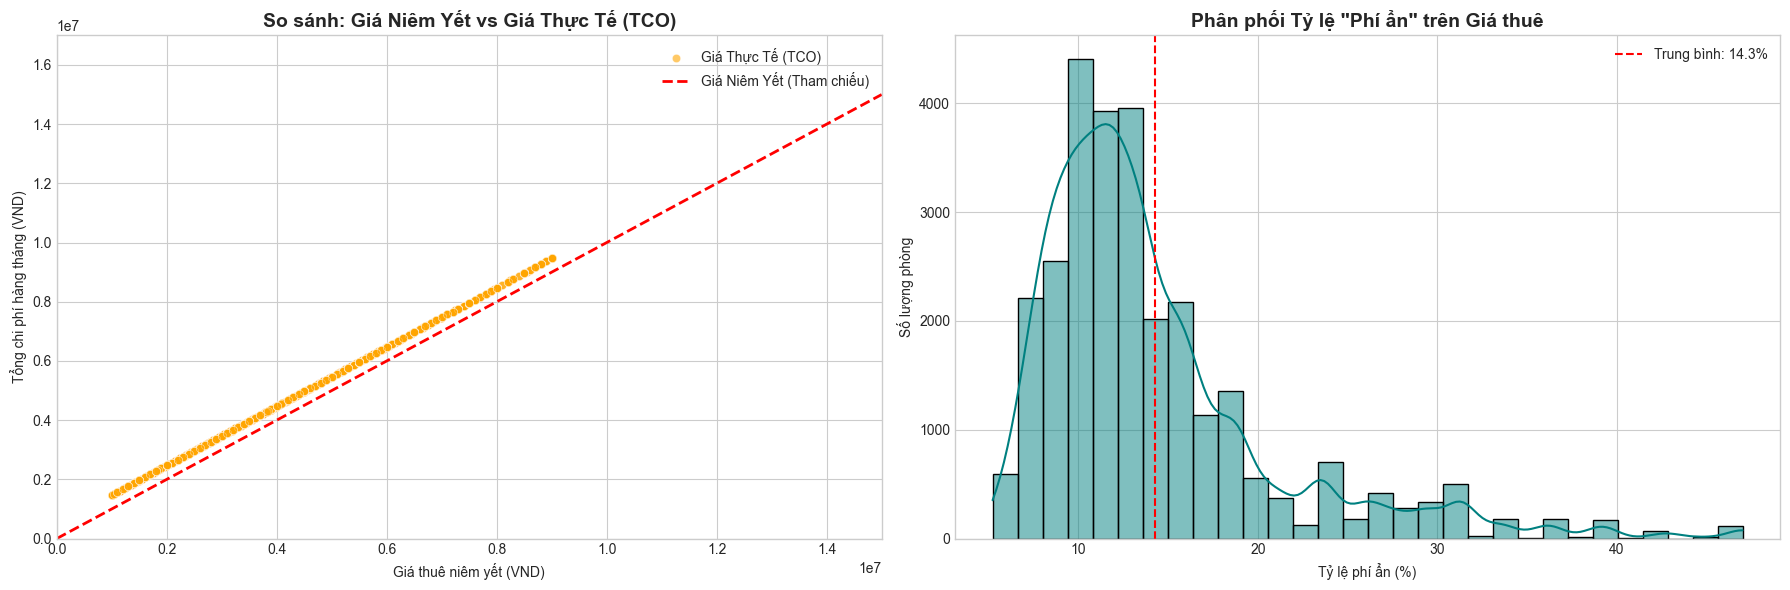

💡 Insight: Trung bình mỗi tháng, sinh viên phải trả thêm khoảng 470,000 VND cho các dịch vụ đi kèm.


In [7]:
# --- XỬ LÝ DỮ LIỆU & TÍNH TOÁN TCO ---

# 1. Khởi tạo các cột chi phí nếu chưa có (Dựa trên dữ liệu mẫu hoặc mặc định)
# Lưu ý: Nếu dataset của bạn thiếu các cột này, code sẽ tự động điền giá trị trung bình thị trường.
avg_market_prices = {
    'electric_price': 3500,   # 3.5k/kWh
    'water_price': 100000,    # 100k/người
    'garbage_price': 20000,   # 20k/tháng
    'service_price': 0        # Mặc định 0 nếu không ghi
}

for col, default_val in avg_market_prices.items():
    if col not in df.columns:
        df[col] = default_val # Tạo cột giả định nếu thiếu
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(default_val)

# 2. Hàm tính chi phí Nước (Phân biệt đơn giá Khối vs Trọn gói)
def calculate_water_cost(price):
    if price < 30000: # Nếu đơn giá < 30k -> Có thể là giá theo m3
        return price * 4 # Giả định dùng 4 khối/tháng
    return price # Nếu giá >= 30k -> Coi là giá trọn gói/người

df['est_water_cost'] = df['water_price'].apply(calculate_water_cost)

# 3. Tính Tổng Chi phí Tiện ích (Utility Cost)
df['total_utility_cost'] = (
    (df['electric_price'] * 100) +  # 100 số điện
    df['est_water_cost'] +
    df['garbage_price'] +
    df['service_price']
)

# 4. Tính TCO và Tỷ lệ Phí ẩn
df['TCO'] = df['price'] + df['total_utility_cost']
df['hidden_fee_ratio'] = (df['total_utility_cost'] / df['price']) * 100

# --- TRỰC QUAN HÓA KẾT QUẢ ---

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Scatter Plot - Giá Niêm Yết vs Giá Thực Tế
sns.scatterplot(
    x='price', y='TCO', data=df,
    ax=axes[0], color='orange', alpha=0.6, label='Giá Thực Tế (TCO)'
)
# Vẽ đường tham chiếu y=x (Nếu không có phí ẩn)
max_val = 15000000 # Giới hạn hiển thị 15 triệu cho đẹp
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Giá Niêm Yết (Tham chiếu)')
axes[0].set_title('So sánh: Giá Niêm Yết vs Giá Thực Tế (TCO)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá thuê niêm yết (VND)')
axes[0].set_ylabel('Tổng chi phí hàng tháng (VND)')
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val + 2000000)
axes[0].legend()

# Biểu đồ 2: Phân phối Tỷ lệ Phí ẩn (%)
sns.histplot(df['hidden_fee_ratio'], bins=30, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Phân phối Tỷ lệ "Phí ẩn" trên Giá thuê', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tỷ lệ phí ẩn (%)')
axes[1].set_ylabel('Số lượng phòng')
# Thêm đường trung bình
mean_ratio = df['hidden_fee_ratio'].mean()
axes[1].axvline(mean_ratio, color='red', linestyle='--', label=f'Trung bình: {mean_ratio:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"💡 Insight: Trung bình mỗi tháng, sinh viên phải trả thêm khoảng {df['total_utility_cost'].mean():,.0f} VND cho các dịch vụ đi kèm.")